# HW 15 - Animation
ULAB - Physics and Astronomy Division \
Due **Sunday, March 9th, 2025 at 11:59pm** on Gradescope

## 1 Modify the Animation from Lecture
Modify the given sine wave animation so that the wave moves twice as fast. What parts of the code you you need to change, and why? Please specifically highlight this in your code

In [ ]:
# Importing all of the needed built in functions
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Defining x, y in the sine functions
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

# Creates the drawing space and unpacking the tuple
fig, ax = plt.subplots()
line, = ax.plot(x, np.sin(x))

# Updates the sine wave
def update(frame):
    line.set_ydata(np.sin(x + frame / 5.0)) # Using 5.0 instead of 10.0
    return line, 

# Animates the function
ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=False)

# Displays function
plt.show()

In [ ]:
# Instead of using 10 in line.set_ydata(np.sin(x + frame / 10.0), I used 5.0 because it 
# increases the frame rate, thus increasing the animation.

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [ ]:
# Saving animation
ani.save("animation.gif", writer="pillow", fps=20)

Explain what happens if you set `blit=True` in `FuncAnimation`? What happens if you set it to `blit=False`?

In [ ]:
# If you set blit = True in the FuncAnimation, it allows the code to run smoother. It 
# will only redraw the elements that get updates by the update function, not the entire
# graph. If blit = False, the whole figure will be redrawn every time, which slows down
# the animation.

## 2 A Different Animation
Write an animation where a dot moves in a circular path instead of sine wave. *Hint: You will need to use `np.sin` and `np.cos`. 

In [ ]:
# Creates the drawing space and unpacking the tuple
fig, ax = plt.subplots()
ax.set_xlim(-2.0, 2.0) # Edits the axis so that the circle can been seen in the animation
ax.set_ylim(-2.0, 2.0)

# Create the moving dot (instead of a line)
dot, = ax.plot([], [], 'bo') # Makes the dot blue (that way it is visible)

# Updates the dot
def update(frame):
    x = np.cos(2 * np.pi * frame / 100.0) # Uses cosine to create the circle (also changed the speed to 100.0 because 10.0 was way too fast)
    y = np.sin(2 * np.pi * frame / 100.0) # Uses sine to create the circle
    dot.set_data([x], [y])  # Pass as sequences (I kept getting an error message and was confused so I did have to look this up)
    return dot,

# Animates the function
ani = animation.FuncAnimation(fig, update, frames=100, interval=50, blit=True)

# Displays function
plt.show()

Save the animation as a .mp4 or a .gif and include it you repository for submission. 

In [ ]:
ani.save("animation_circle.gif", writer="pillow", fps=20)

## 3 Simulate Orbital Motion of Planets and a Comet
**Check out the `example_solar_system_animation.mp4` as an example of what you will be creating in this problem.**

Now you will simulate and visualize the orbital motion of Earth, Mars and a coment around the Sun using Newtonian gravity and Python. Here are the steps:
* Calculate the gravitational forces acting on each body.
* Update positions and velocities over time.
* Simulate the motion of these celestial bodies over a period of 5 years.
* Animate the results to observe orbital patterns. 

Let's dig a bit into the physics. The motion of celestial bodies follows **Newton's laws of motion and gravitation**:
$$
F = G \frac{m_1 m_1}{r^2}
$$

where:
* $F$ is the gravitational force.
* $G = 6.67\times10^{-11}$ is the gravitational constant
* $m_1$, $m_2$ are the measses of the two objects.
* $r$ is the distance between them.

Using **Newton's Second Law**, the acceleration is given by:

$$
a = \frac{F}{m}
$$

where $a$ is the acceleration, and $m$ is the object's mass. The velocity and position are updated with numerical integration:

$$
v = v + a \cdot dt
$$

$$
x = x + v \cdot dt
$$

## 3.1 Implementing the Simulation
Goal: Set up the **masses**, **initial positions** and **velocities** for the Sun, Earth, Mars and a comet. 
* Use SI units (meters, kilograms, seconds).
* The Sun is at the origin (0, 0, 0)
* Earth, Mars and the commet start at **aphelion** (farthest from the Sun).

Start by defining the following initial variables in kilograms (or SI units):
* `G`
* `Ms` (the mass of the Sun, you will need to google this)
* `Me` (the mass of the Earth)
* `Mm` (the mass of Mars)
* `Mc = 6.39e20` (the mass of a comet)
* `AU` (astronomical unit, distance between Earth and the Sun)
* `daysec` (how many seconds are in a day)

In [ ]:
# I kept getting this error message, when trying to open up the example: /Users/oliviawagner/ulab/ulab_olivia/homework15/example_solar_system_animation.mp4 is not UTF-8 encoded

G = 6.67 * 10 ** -11
Ms = 1.98 * 10 ** 30 # kg
Me = 5.97 * 10 ** 24 # kg
Mm = 6.42 * 10 ** 23 # kg
Mc = 2.2 * 10 ** 14 # kg
AU = 1.496 * 10 ** 11 # meters
daysec = 86400 # seconds

Now we will define some initial velocities in meters per second:
* `e_ap_v` (Earth at aphelion, google it, make sure its in SI units)
* `m_ap_v` (Mars at aphelion)
* `commet_v = 7000` (speed of the comet)

In [ ]:
e_ap_v = 29.29 # km/s
m_ap_v = 21.97 # km/s
commet_v = 7000 # m/s

Run the cell below to define some gravitational constants because we expect no mass loss:

In [ ]:
gravconst_e = 6.67430 * 10 ** -11
gravconst_m = 6.67430 * 10 ** -11
gravconst_c = 6.67430 * 10 ** -11

Define the initial positions of the Earth, Mars and the comet. Here is the Earth as an example:
* `xe, ye, ze = 1.0167 * AU, 0, 0`

Follow the same pattern for Mars (where the `x` coordinate is at `1.666 * AU`, everything else is zero) and the comet (where the `x` coordinate is at `2* AU`, the `y` coordinate is `0.3 * AU` and the `z` coordinate is zero) . Remember the sun is at the origin! 

In [ ]:
xe, ye, ze = 1.0167 * AU, 0, 0
xm, ym, zm = 1.666 * AU, 0, 0
xc, yc, zc = 2 * AU, 0.3 * AU, 0
xs, ys, zs = 0, 0, 0

We will do the same thing but for initial velocities. Here is Earth as an example:
* `xve, yve, zve = 0, e_ap_v, 0`

Make variables for Mars but with `m_ap_v` as the `y` coordinate. Make variables for the commet but with `commet_v` as the `y` coordinate.

In [ ]:
xve, yve, zve = 0, e_ap_v, 0
xvm, yvm, zvm =0, m_ap_v, 0
xvc, yvc, zvc = 0, commet_v, 0

Assume the Sun is at the origin. Make initial positions and velocities for the Sun. It should not be moving so all its velocities coordinates are zero. 

In [ ]:
xvs, yvs, zvs = 0, 0, 0

Now we will define some time parameters for our simulation. Create variable for the initial time `t` and set it to zero. Create a variable called `dt` for the change in time (steps per day) and set it to `1 * daysec`. Create a varible for `years` and set it to `5`. Finally, create a varible for `sim_years` and set it equal to `years * 365 * daysec`.

In [ ]:
t = 0
dt = 1 * daysec
years = 5
sim_years = years * 365 * daysec

Create empty lists to store all of your varibles. Run the cell below.

In [ ]:
# Store the orbits:
xelist = []
yelist = []
xmlist = []
ymlist = []
xclist = []
yclist = []
xslist = []
yslist = []

## 3.2 Compute Gravitational Forces and Update Positions
Goal:
* Implement the **gravitational force equation** to calculate the force acting on each body.
* Compute accelerations using $a = F/m$.
* Update **velocity** and **position**.
* Use a loop to update positions over **5 years**.
* Store the results in lists for plotting.

I will do this part for you, it requires some physics knowledge. But you need to turn this into a loop for when time is less than the simulation time. You want the loop to repeat it itself until that condition is met. 

In [ ]:
while t < sim_years: # while loop
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)
    
    t += dt

## 3.3 Visualization
Goal: Plot the Orbits
* After simulating the motion, **plot the orbits of Earth, Mars and the comet**.
* Label the **Sun**, **Earth**, **Mars**, and **Comet**.

Start by making a figure, set the argument of`figsize=(8, 8)`.
* Plot the `yelist` as a function of `xelist`. Do this for the `xm`, `xc` and `xs` lists as well. Make sure each line is a **different color**!
  * The Sun will just be a point, so give it a markersize of `10`. Make it yellow.  
* Give it a legend
* Add an `xlabel` of `"X Position (m)"`.
* Add an `ylabel` of `"Y Position (m)"`.
* Give it a title.
* Add a grid.
* Show the plot.

In [ ]:
# Making figure
plt.figure(figsize=(8, 8))

# Plot information
plt.plot(xelist, yelist, label = 'Earth', color = 'green')
plt.plot(xmlist, ymlist, label = 'Mars', color = 'red')
plt.plot(xclist, yclist, label = 'Comet', color = 'black')
plt.scatter(xslist[0], yslist[0], label = 'Sun', color = 'yellow', s = 100)

# Plot labels from directions
plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

# Plot title
plt.title("Orbits of Planetary Objects")

# Grid on plot
plt.grid(True)

# Creates legend
plt.legend()

plt.show()


# The example will not load on my computer so I don't know if this is exactly what the plot should look like.

Goal: Animate the Motion
* Create an animated visualization of planetary orbits.
* Track the motion of each body over time.

\
Follow the procedure from lecture. Here are some hints:
* Set the `x` and `y` limits to `-3 * AU` to `3 * AU`. \


* Unpack the lines for Earth, Mars, the commet. Example: 
  * `line_e = axplot([], [], '-g', lw=1)` \

  
* Unpack the points for Earth, Mars, the commet and the Sun. Example:
  * `point_e, = ax.plot([],[],'bo',markersize=4)` \

* Give a title to each of the objects. Example:
  * `text_e  = ax.text(AU,0,'Earth')`

* Create the `update` function and update the lines, points and text you just unpacked. Example:
  * `line_e.set_data(xelist[:i], yelist[:i])` 
  * `point_e.set_data(xelist[i], yelist[i])`\
  * `text_e.set_position((xelist[i],yelist[i]))`


* Create the animation! Set `frames = len(xelist)`, `interval=1` and `blit=True`. 

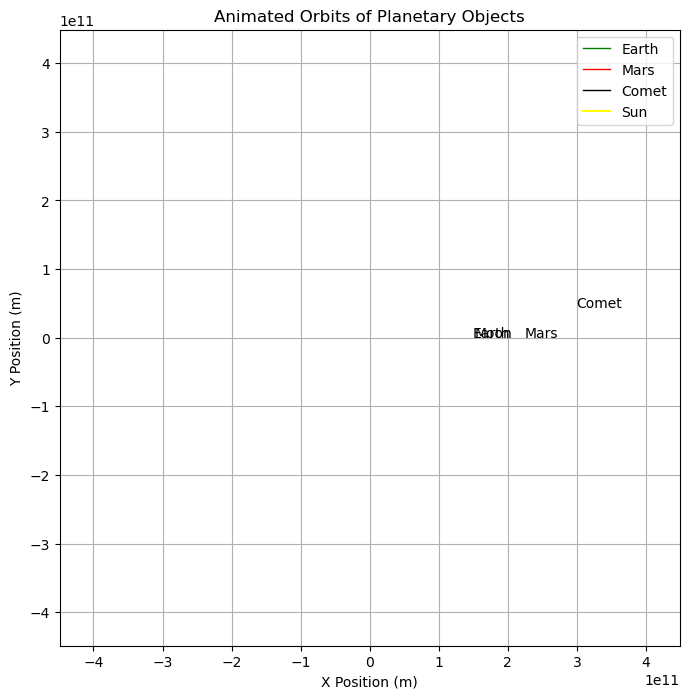

In [101]:
fig, ax = plt.subplots(figsize = (8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

line_e, = ax.plot([], [], '-g', lw = 1, label = 'Earth') # -g = color of line
line_m, = ax.plot([], [], '-r', lw = 1, label = 'Mars')
line_c, = ax.plot([], [], '-k', lw = 1, label = 'Comet')

point_e, = ax.plot([], [], 'green', markersize = 4)
point_m, = ax.plot([], [], 'red', markersize = 4)
point_c, = ax.plot([], [], 'black', markersize = 4)
point_s, = ax.plot([0], [0], 'yellow', markersize = 8, label = 'Sun')

text_e = ax.text(1 * AU, 0, 'Earth')
text_m = ax.text(1.5 * AU, 0, 'Mars')
text_c = ax.text(2 * AU, 0.3 * AU, 'Comet')

ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Animated Orbits of Planetary Objects")
ax.grid(True)

def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])
    return line_e, line_m, line_c

ani = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit = True)
plt.show()

## 3.4 Add Mercury, Venus and the Moon!
As an extra challenge, give your best attempt at simulating Mercury, Venus and/or the Moon! I am not going to give you a ton of hints for this problem. Come to office hours if you have questions :)

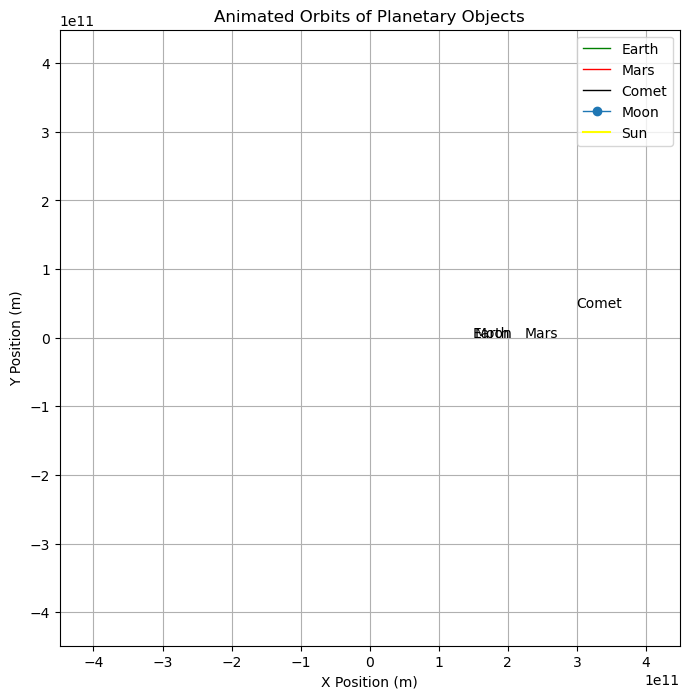

In [102]:
# Constants associated with the moon
Mmoon = 7.347 * 10 ** 22
moon_distance = 3.844 * 10 ** 8
moon_velocity = 1022

# The initial position of the moon
xmoon, ymoon, zmoon = xe, ye + moon_distance, 0

# The initial velocities of the moon 
xvmoon, yvmoon = xve, yve + moon_velocity

# Empty lists for the moon
xmoonlist = []
ymoonlist = []

# Updating positions (including moon)
while t < sim_years:
    ################ Earth #############
    rx, ry, rz = xe - xs, ye - ys, ze - zs
    modr3_e = (rx**2 + ry**2 + rz**2)**1.5
    fx_e = -gravconst_e * rx / modr3_e
    fy_e = -gravconst_e * ry / modr3_e
        
    xve += fx_e * dt / Me
    yve += fy_e * dt / Me
    xe += xve * dt
    ye += yve * dt
        
    xelist.append(xe)
    yelist.append(ye)
    
    ################ Mars ##############
    rx_m, ry_m, rz_m = xm - xs, ym - ys, zm - zs
    modr3_m = (rx_m**2 + ry_m**2 + rz_m**2)**1.5
    fx_m = -gravconst_m * rx_m / modr3_m
    fy_m = -gravconst_m * ry_m / modr3_m
        
    xvm += fx_m * dt / Mm
    yvm += fy_m * dt / Mm
    xm += xvm * dt
    ym += yvm * dt
        
    xmlist.append(xm)
    ymlist.append(ym)
    
    ################ Comet ##############
    rx_c, ry_c, rz_c = xc - xs, yc - ys, zc - zs
    modr3_c = (rx_c**2 + ry_c**2 + rz_c**2)**1.5
    fx_c = -gravconst_c * rx_c / modr3_c
    fy_c = -gravconst_c * ry_c / modr3_c
        
    xvc += fx_c * dt / Mc
    yvc += fy_c * dt / Mc
    xc += xvc * dt
    yc += yvc * dt
        
    xclist.append(xc)
    yclist.append(yc)
    
    ################ Sun ##############
    xvs += -(fx_e + fx_m) * dt / Ms
    yvs += -(fy_e + fy_m) * dt / Ms
    xs += xvs * dt
    ys += yvs * dt
    xslist.append(xs)
    yslist.append(ys)

    ################ Moon ##############
    rx_moon, ry_moon, rz_moon = xmoon - xe, ymoon - ye, zmoon - ze
    modr3_moon = (rx_moon**2 + ry_moon**2 + rz_moon**2)**1.5
    fx_moon = -G * Me * Mmoon * rx_moon / modr3_moon
    fy_moon = -G * Me * Mmoon * ry_moon / modr3_moon

    xvmoon += fx_moon * dt / Mmoon
    yvmoon += fy_moon * dt / Mmoon
    xmoon += xvmoon * dt
    ymoon += yvmoon * dt

    xmoonlist.append(xmoon)
    ymoonlist.append(ymoon)
    t += dt

# Animation time
fig, ax = plt.subplots(figsize = (8, 8))
ax.set_xlim(-3 * AU, 3 * AU)
ax.set_ylim(-3 * AU, 3 * AU)

line_e, = ax.plot([], [], '-g', lw = 1, label = 'Earth') # -g (as well as -r, -k, and -o) is the color of the line
line_m, = ax.plot([], [], '-r', lw = 1, label = 'Mars')
line_c, = ax.plot([], [], '-k', lw = 1, label = 'Comet')
line_moon, = ax.plot([], [], '-o', lw = 1, label = 'Moon')

point_e, = ax.plot([], [], 'green', markersize = 4)
point_m, = ax.plot([], [], 'red', markersize = 4)
point_c, = ax.plot([], [], 'black', markersize = 4)
point_s, = ax.plot([0], [0], 'yellow', markersize = 8, label = 'Sun')
point_moon, = ax.plot([], [], 'orange', markersize = 4)

text_e = ax.text(AU, 0, 'Earth')
text_m = ax.text(1.5 * AU, 0, 'Mars')
text_c = ax.text(2 * AU, 0.3 * AU, 'Comet')
text_moon = ax.text(1.01 * AU, 0, 'Moon') # Slightly changed the values from Earth, but very similar


ax.legend()
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_title("Animated Orbits of Planetary Objects")
ax.grid(True)

def update(i):
    line_e.set_data(xelist[:i], yelist[:i])
    line_m.set_data(xmlist[:i], ymlist[:i])
    line_c.set_data(xclist[:i], yclist[:i])
    line_moon.set_data(xmoonlist[:i], ymoonlist[:i])
    return line_e, line_m, line_c, line_moon

anim = animation.FuncAnimation(fig, update, frames = len(xelist), interval = 1, blit = True)
plt.show()

Save you animation as a `.gif` or as a `.mp4`. Include this in your submission! This may take up to a couple mintutes!

In [ ]:
# Your code here
anim.save("animation.mp4", writer="pillow", fps=20)

Upload this notebook and your animations to Gradescope!